### Dados Utilizados:
Nascimentos e Mortes em Porto Alegre

SINASC - Sistema de Informações de Nascidos Vivos
> https://dadosabertos.poa.br/dataset/sinasc

SIM - Sistema de Informações de Mortalidade
> https://dadosabertos.poa.br/dataset/mortalidade-e-obitos

DataSUS - CID-10
> http://www2.datasus.gov.br/cid10/V2008/cid10.

### Problema inicial:
Analisar ambas as bases de dados e mostrar:
- Mortes por Mês/Ano
- Homicídios por Mês/Ano
- Total de homicídios por ano
- Total de Nascimentos por ano
- Comparação de Nascimentos e Mortes por Ano
- Top 3 Grupo CID-10 com Maior Número de Mortes por Ano
- Top 5 Subcategorias CID dos 3 Grupos CID mais comuns

In [210]:
import pandas as pd
print(pd.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

#criando categorias

df = pd.read_csv('sim_obitos.csv',delimiter=";")
df["obito"] = pd.to_datetime(df["obito"], format='%m/%Y')
df['sexo'] = df['sexo'].astype("category")
df['tipo_obito'] = df['tipo_obito'].astype("category")
df['cid_causa_basica'] = df['cid_causa_basica'].astype("category")

df['circunstancia_obito'] = df['circunstancia_obito'].astype(str).str.strip()

# Correção: Extrair os primeiros 3 caracteres de 'cid_causa_basica' para obter o grupo CID
df['cid_grupo'] = df['cid_causa_basica'].astype(str).str[:3].astype("category")

df.info()
df.sample()

3.0.6
<class 'pandas.DataFrame'>
RangeIndex: 135548 entries, 0 to 135547
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   data_extracao              135548 non-null  str           
 1   identificador_pessoa2      53961 non-null   str           
 2   obito                      135548 non-null  datetime64[us]
 3   nascimento                 133491 non-null  str           
 4   escolaridade               126107 non-null  str           
 5   sexo                       135440 non-null  category      
 6   raca                       128819 non-null  str           
 7   gestacao                   3493 non-null    str           
 8   gravidez                   3496 non-null    str           
 9   tipo_obito                 135548 non-null  category      
 10  circunstancia_obito        11669 non-null   str           
 11  cid_causa_basica           135547 non-null  category     

,data_extracao,identificador_pessoa2,obito,nascimento,escolaridade,sexo,raca,gestacao,gravidez,tipo_obito,circunstancia_obito,cid_causa_basica,obito_prematuro,obito_mulher_idade_fertil,cid_grupo
41854,2026-07-01,NaN,2014-08-01,03/1920,DE 1 A 3 ANOS,FEMININO,BRANCA,NaN,NaN,NÃO FETAL,NaN,J439,NÃO,NÃO,J43


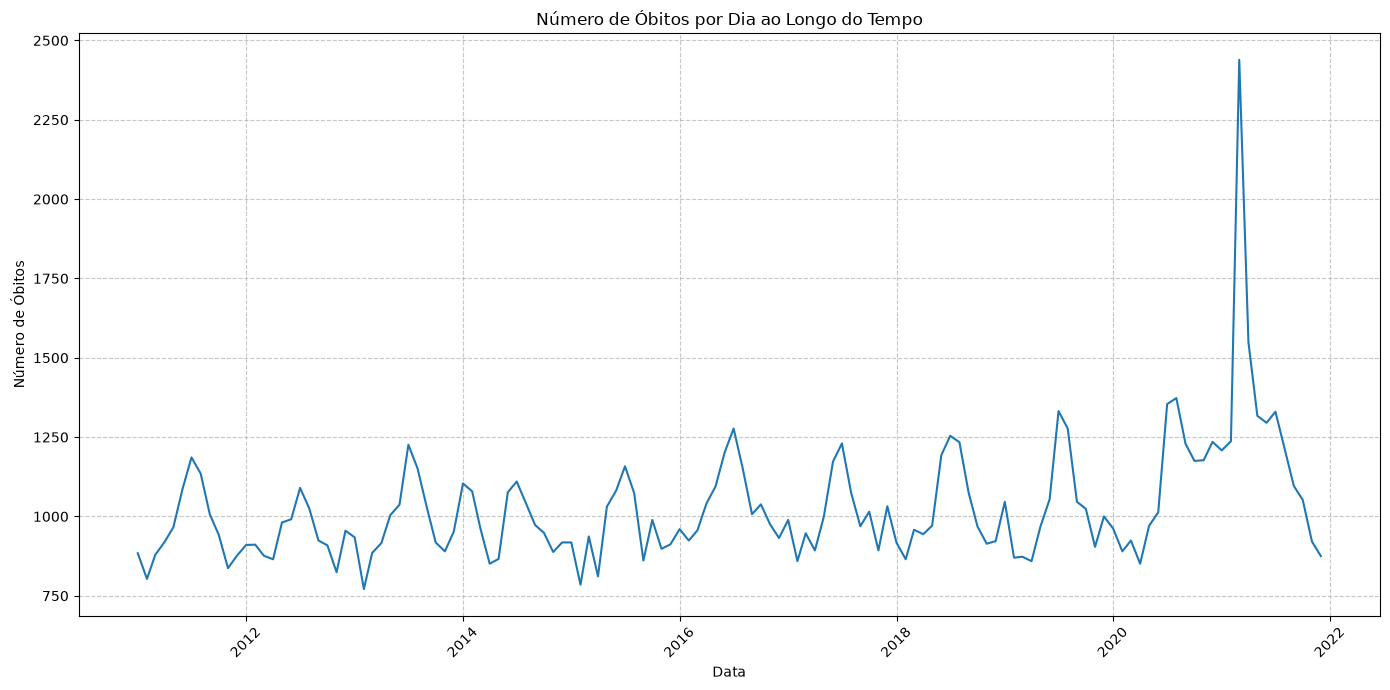

In [197]:
mes = pd.DataFrame(df.groupby([df['obito'].dt.date])['obito'].count())
plt.figure(figsize=(14, 7)) # Define o tamanho da figura para melhor visualização
sns.lineplot(x=mes.index, y="obito", data=mes) # Usa o índice (data) no eixo X para a série temporal
plt.title('Número de Óbitos por Mês ao Longo do Tempo') # Adiciona um título descritivo
plt.xlabel('Data') # Rótulo para o eixo X
plt.ylabel('Número de Óbitos') # Rótulo para o eixo Y
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade para facilitar a leitura
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X para evitar sobreposição
plt.tight_layout() # Ajusta o layout para evitar cortes nos rótulos
plt.show() # Exibe o gráfico

### Vimos um problema?
O que aconteceu em Março de 2021?

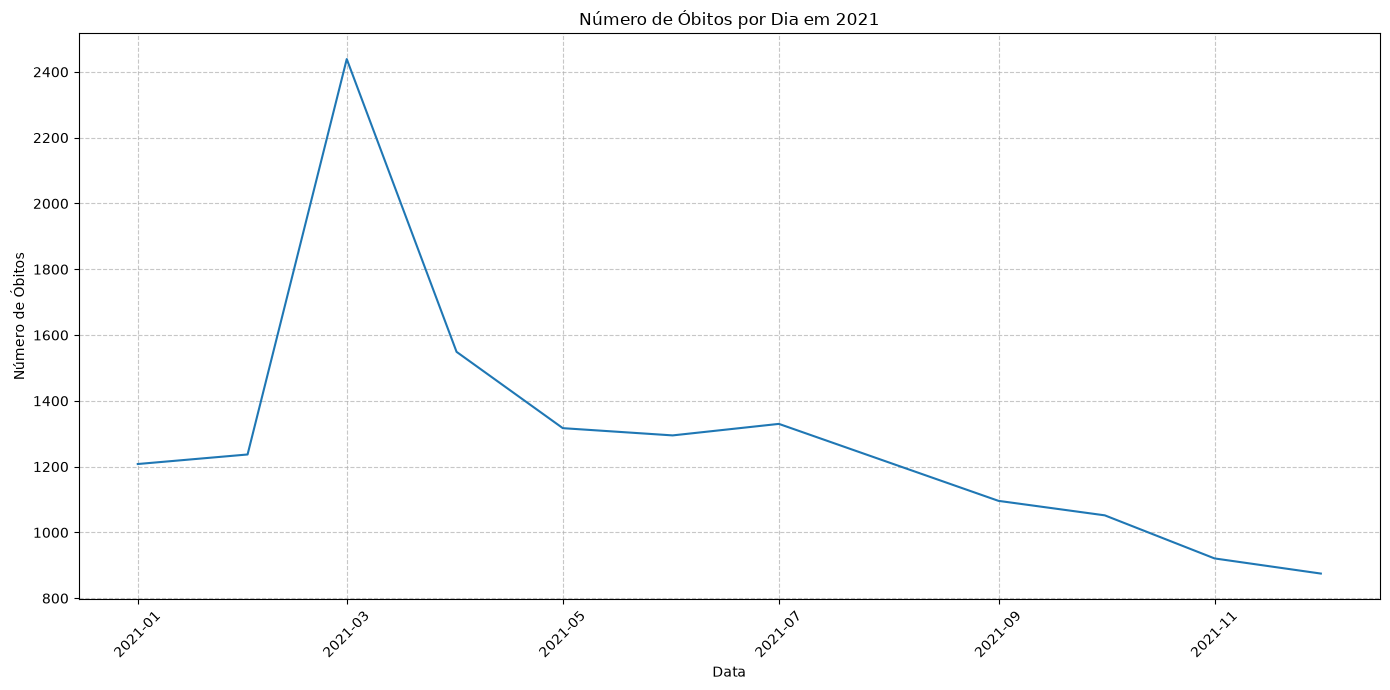

In [198]:
mes = pd.DataFrame(df.groupby([df['obito'].dt.date])['obito'].count())
mes.index = pd.to_datetime(mes.index) # Convertendo o índice para DatetimeIndex
mes_2021 = mes[mes.index.year == 2021]

plt.figure(figsize=(14, 7))
sns.lineplot(x=mes_2021.index, y="obito", data=mes_2021)
plt.title('Número de Óbitos por Dia em 2021')
plt.xlabel('Data')
plt.ylabel('Número de Óbitos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

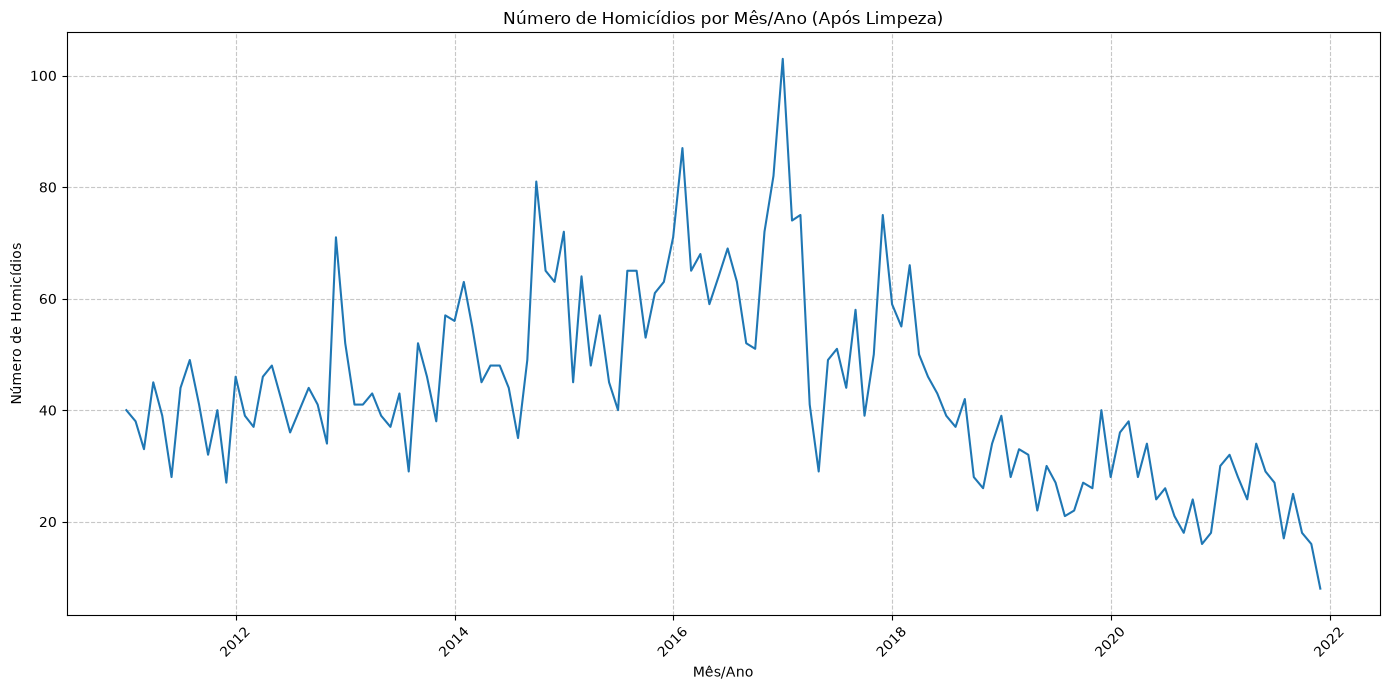

In [199]:
# Filtrando o DataFrame para apenas homicídios (usando a coluna 'circunstancia_obito' limpa)
df_homicidios_limpo = df[df['circunstancia_obito'] == 'HOMICÍDIO']

# Agrupando por mês/ano e contando o número de homicídios
homicidios_mes_ano_limpo = df_homicidios_limpo.groupby([df_homicidios_limpo['obito'].dt.to_period('M')]).size().reset_index(name='Numero_Homicidios')
homicidios_mes_ano_limpo.columns = ['Mes_Ano', 'Numero_Homicidios']

# Convertendo a coluna 'Mes_Ano' para datetime para que o Seaborn possa plotar corretamente
homicidios_mes_ano_limpo['Mes_Ano'] = homicidios_mes_ano_limpo['Mes_Ano'].dt.to_timestamp()

# Plotando o número de homicídios por mês/ano
plt.figure(figsize=(14, 7))
sns.lineplot(x='Mes_Ano', y='Numero_Homicidios', data=homicidios_mes_ano_limpo)
plt.title('Número de Homicídios por Mês/Ano (Após Limpeza)')
plt.xlabel('Mês/Ano')
plt.ylabel('Número de Homicídios')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

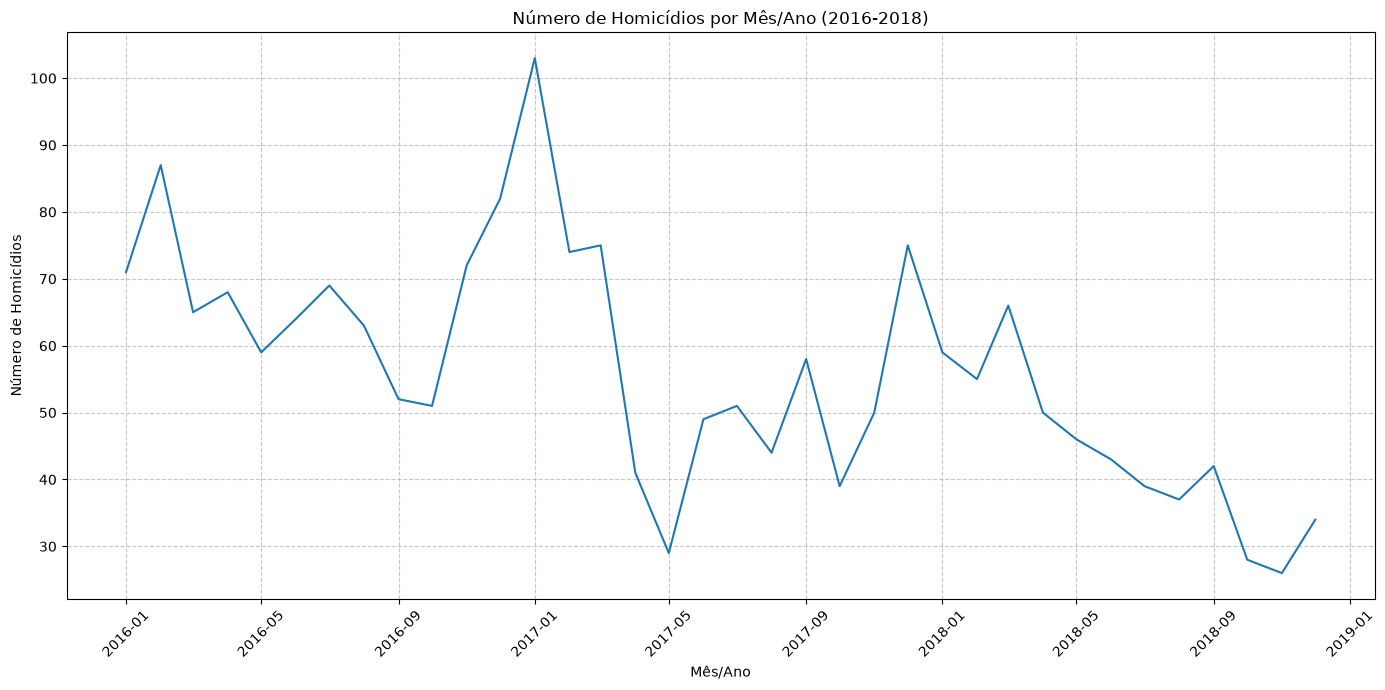

In [200]:
homicidios_2016_2018 = homicidios_mes_ano_limpo[(homicidios_mes_ano_limpo['Mes_Ano'].dt.year >= 2016) & (homicidios_mes_ano_limpo['Mes_Ano'].dt.year <= 2018)]

plt.figure(figsize=(14, 7))
sns.lineplot(x='Mes_Ano', y='Numero_Homicidios', data=homicidios_2016_2018)
plt.title('Número de Homicídios por Mês/Ano (2016-2018)')
plt.xlabel('Mês/Ano')
plt.ylabel('Número de Homicídios')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

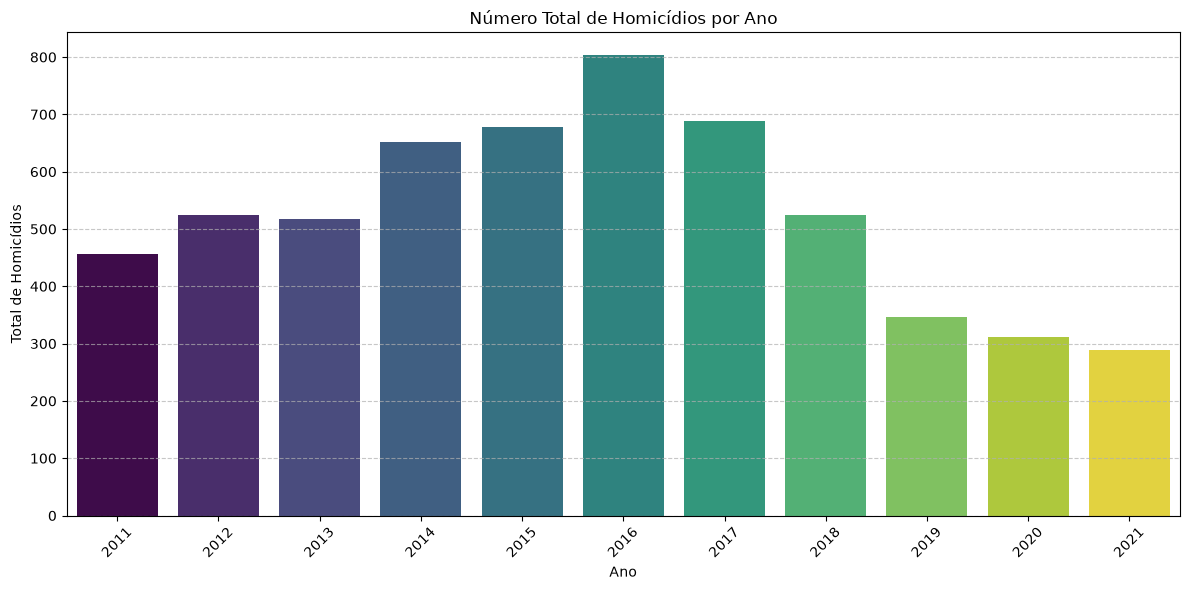

In [201]:
homicidios_por_ano = homicidios_mes_ano_limpo.groupby(homicidios_mes_ano_limpo['Mes_Ano'].dt.year)['Numero_Homicidios'].sum().reset_index()
homicidios_por_ano.columns = ['Ano', 'Total_Homicidios']

plt.figure(figsize=(12, 6))
sns.barplot(x='Ano', y='Total_Homicidios', data=homicidios_por_ano, palette='viridis', hue='Ano', legend=False)
plt.title('Número Total de Homicídios por Ano')
plt.xlabel('Ano')
plt.ylabel('Total de Homicídios')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [202]:
df_nasc = pd.read_csv('sinasc_nascimentos.csv', delimiter=';', low_memory=False)

# Convertendo a coluna 'data_nascimento' para o formato datetime, deixando o Pandas inferir o formato
df_nasc['data_nascimento'] = pd.to_datetime(df_nasc['data_nascimento'], errors='coerce')

# Extraindo o ano da data de nascimento
df_nasc['ano_nascimento'] = df_nasc['data_nascimento'].dt.year

# Removendo valores NaN que podem ter sido gerados pela conversão de data
df_nasc.dropna(subset=['ano_nascimento'], inplace=True)
df_nasc['ano_nascimento'] = df_nasc['ano_nascimento'].astype(int)

# Contando o número de nascimentos por ano
nascimentos_por_ano = df_nasc.groupby('ano_nascimento').size().reset_index(name='Numero_Nascimentos')

C:\Users\bruno\AppData\Local\Temp\ipykernel_22220\4232451636.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_nasc['data_nascimento'] = pd.to_datetime(df_nasc['data_nascimento'], errors='coerce')


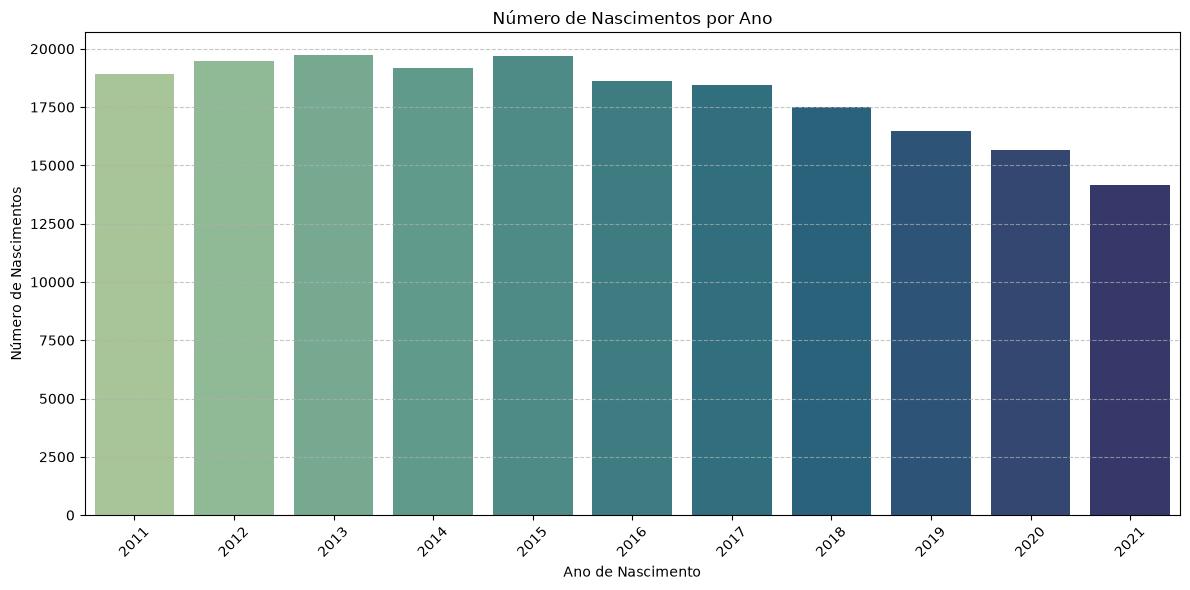

In [203]:
plt.figure(figsize=(12, 6))
sns.barplot(x='ano_nascimento', y='Numero_Nascimentos', data=nascimentos_por_ano, palette='crest', hue='ano_nascimento', legend=False)
plt.title('Número de Nascimentos por Ano')
plt.xlabel('Ano de Nascimento')
plt.ylabel('Número de Nascimentos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [204]:
total_mortes_por_ano = df.groupby(df['obito'].dt.year).size().reset_index(name='Total_Mortes')
total_mortes_por_ano.columns = ['Ano', 'Total_Mortes']

df_comparacao_total_mortes = pd.merge(nascimentos_por_ano, total_mortes_por_ano, left_on='ano_nascimento', right_on='Ano', how='inner')
df_comparacao_total_mortes = df_comparacao_total_mortes.drop(columns='Ano') # Remove a coluna 'Ano' duplicada
df_comparacao_total_mortes.rename(columns={'ano_nascimento': 'Ano', 'Numero_Nascimentos': 'Nascimentos', 'Total_Mortes': 'Mortes'}, inplace=True)

df_melted_total_mortes = df_comparacao_total_mortes.melt(id_vars='Ano', var_name='Tipo', value_name='Numero')

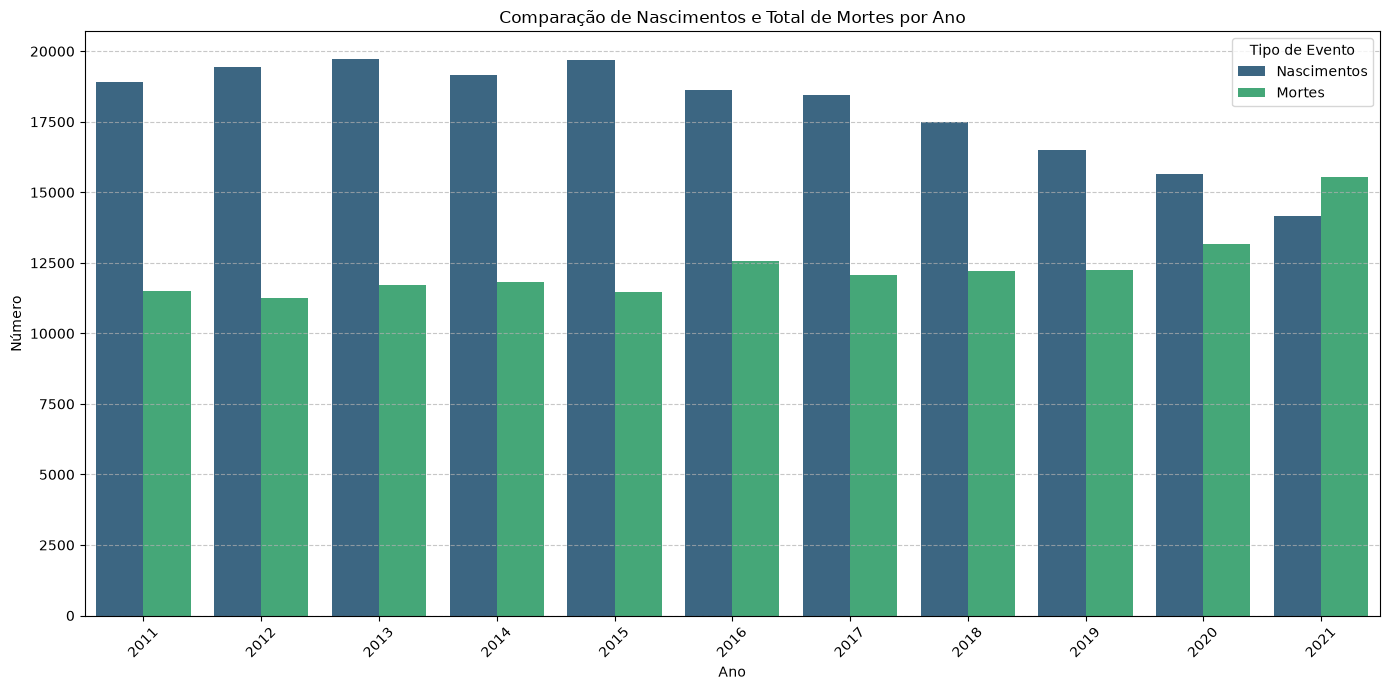

In [205]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Ano', y='Numero', hue='Tipo', data=df_melted_total_mortes, palette='viridis')
plt.title('Comparação de Nascimentos e Total de Mortes por Ano')
plt.xlabel('Ano')
plt.ylabel('Número')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Evento')
plt.tight_layout()
plt.show()

In [206]:
df['Mes_Ano_Obito'] = df['obito'].dt.to_period('M')
mortes_por_cid_grupo_mes_ano = df.groupby(['cid_grupo', 'Mes_Ano_Obito'], observed=True).size().reset_index(name='Numero_Mortes')
mortes_por_cid_grupo_mes_ano['Mes_Ano_Obito'] = mortes_por_cid_grupo_mes_ano['Mes_Ano_Obito'].dt.to_timestamp()
df_cid10 = pd.read_csv('CID-10\\CID-10-GRUPOS.CSV', delimiter=';', encoding='latin-1')
df_cid10 = df_cid10[['CATINIC', 'DESCRICAO']]
df_cid10.columns = ['cid_grupo', 'label_cid_grupo']
mortes_com_label_cid = pd.merge(mortes_por_cid_grupo_mes_ano, df_cid10, on='cid_grupo', how='left')
causas_frequentes = mortes_com_label_cid.groupby('label_cid_grupo')['Numero_Mortes'].sum().reset_index()
causas_frequentes = causas_frequentes.sort_values(by='Numero_Mortes', ascending=False)
mortes_com_label_cid['Ano'] = mortes_com_label_cid['Mes_Ano_Obito'].dt.year
mortes_por_ano_cid = mortes_com_label_cid.groupby(['Ano', 'label_cid_grupo'])['Numero_Mortes'].sum().reset_index()
top_5_causas_por_ano = (
    mortes_por_ano_cid
    .sort_values(['Ano', 'Numero_Mortes'], ascending=[True, False])
    .groupby('Ano', group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

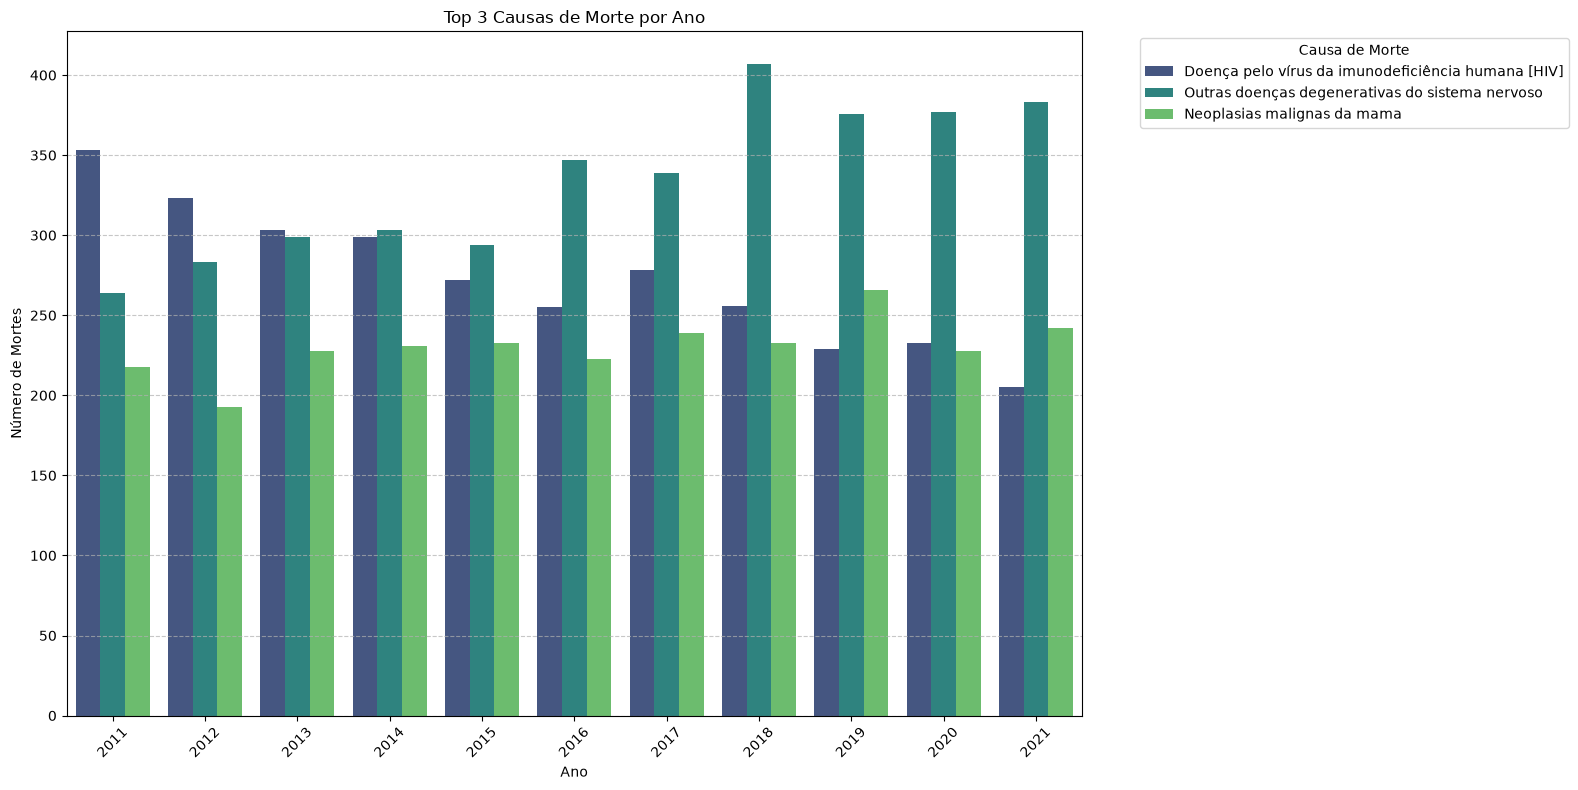

In [ ]:
plt.figure(figsize=(16, 8))
sns.barplot(x='Ano', y='Numero_Mortes', hue='label_cid_grupo', data=top_5_causas_por_ano, palette='viridis')
plt.title('Top 3 Grupo CID-10 com Maior Número de Mortes por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Mortes')
plt.xticks(rotation=45)
plt.legend(title='Causa de Morte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [208]:
df_subcategorias = pd.read_csv('CID-10/CID-10-SUBCATEGORIAS.CSV', delimiter=';', encoding='latin-1')
df_subcategorias = df_subcategorias[['SUBCAT', 'DESCRICAO']]
df_subcategorias.columns = ['subcategoria', 'label_subcategoria']
df['cid_causa_basica'] = df['cid_causa_basica'].astype(str).str.strip()
df_com_subcategorias = pd.merge(df, df_subcategorias, left_on='cid_causa_basica', right_on='subcategoria', how='left')


--- Top 5 Subcategorias para o Grupo: Outras doenças degenerativas do sistema nervoso ---


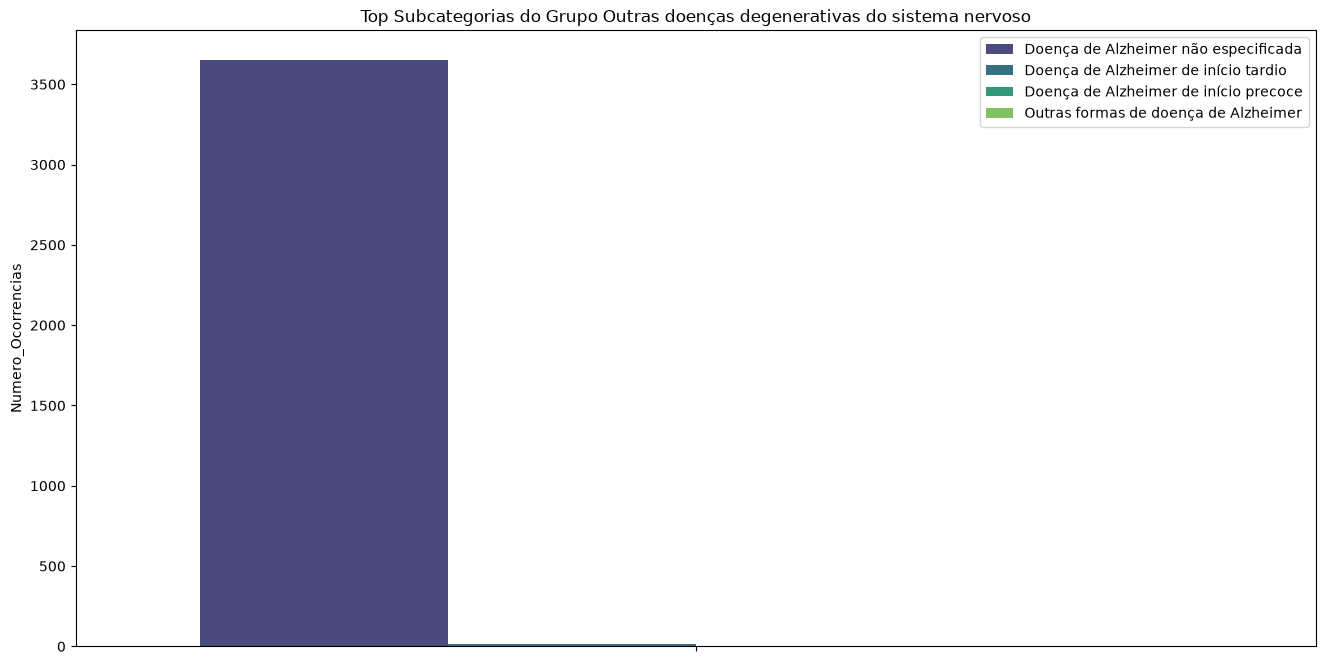


--- Top 5 Subcategorias para o Grupo: Doença pelo vírus da imunodeficiência humana [HIV] ---


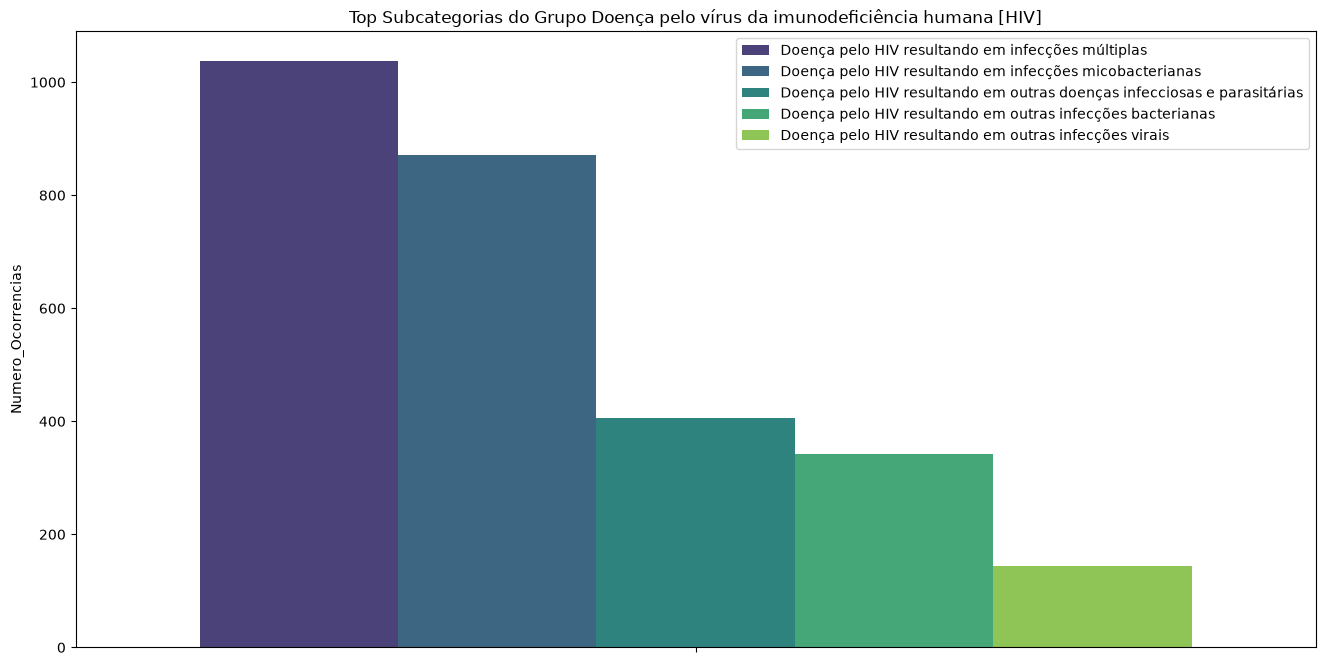


--- Top 5 Subcategorias para o Grupo: Neoplasias malignas da mama ---


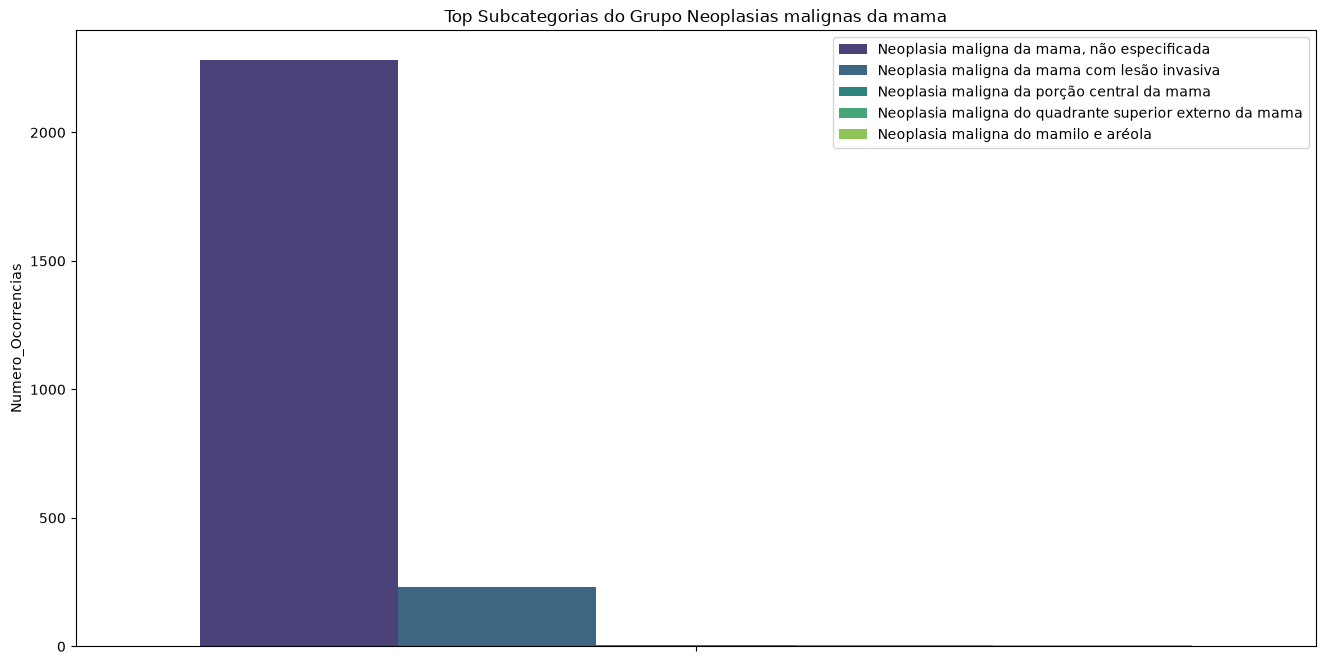

In [ ]:
top_3_cid_grupos_labels = causas_frequentes['label_cid_grupo'].head(3).tolist()

df_temp = pd.merge(df_com_subcategorias, df_cid10, left_on='cid_grupo', right_on='cid_grupo', how='left')

df_top_3_grupos = df_temp[df_temp['label_cid_grupo'].isin(top_3_cid_grupos_labels)]

resultados_top_subcategorias = {}
for grupo_label in top_3_cid_grupos_labels:
    df_grupo = df_top_3_grupos[df_top_3_grupos['label_cid_grupo'] == grupo_label]
    top_5_sub = df_grupo['label_subcategoria'].value_counts().head(5).reset_index()
    top_5_sub.columns = ['Subcategoria', 'Numero_Ocorrencias']
    resultados_top_subcategorias[grupo_label] = top_5_sub

for grupo, df_res in resultados_top_subcategorias.items():
    plt.figure(figsize=(16, 8))
    plt.title(f'Top 5 Subcategorias para o Grupo: {grupo}')
    sns.barplot(y='Numero_Ocorrencias', hue='Subcategoria', data=df_res, palette='viridis')
    plt.title(f'Top Subcategorias do Grupo {grupo}')
    plt.legend(loc='upper right')
    plt.show()